In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score


## Pipeline

### Preprocessing

PCA Visualization

In [93]:
data_path = 'Torgo_selected.csv'

In [94]:
torgo = pd.read_csv(data_path)

torgo_2 = torgo.copy()
y = torgo['label']
X = torgo.drop('label', axis=1)

In [95]:
torgo.isna().sum().sum()

np.int64(0)

In [96]:
# scaler = StandardScaler()
scaler = PowerTransformer()
X = scaler.fit_transform(X)

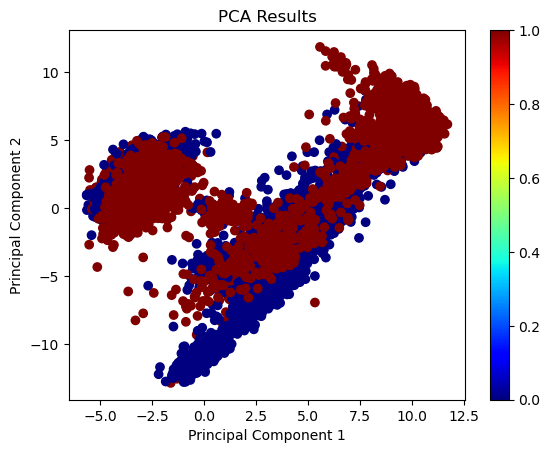

In [97]:
pca = PCA(n_components = 2, random_state=42)
X_pca = X.copy()
X_pca  = pca.fit_transform(X_pca)

plt.scatter(X_pca[: , 0], X_pca[: , 1], c=y.astype(int), cmap="jet")
plt.title("PCA Results")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

t-SNE Visualization

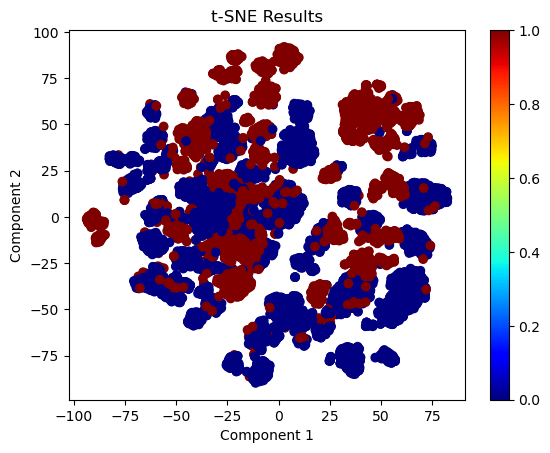

In [98]:
tsne = TSNE(n_components = 2, random_state=42)
X_tsne = X.copy()
X_tsne = tsne.fit_transform(X_tsne)

plt.scatter(X_tsne[: , 0], X_tsne[: , 1], c=y.astype(int), cmap="jet")
plt.title("t-SNE Results")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()

Decide number of relevant components to 95% of relevant information

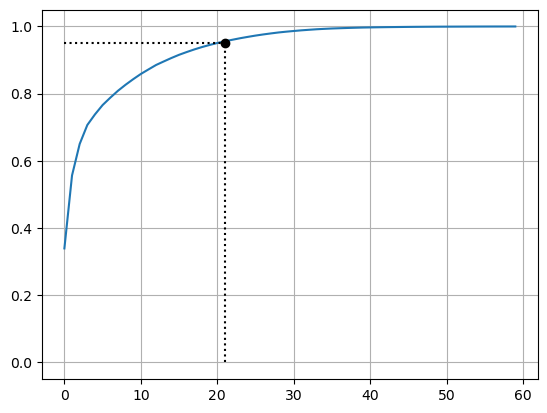

In [99]:
pca = PCA(random_state=42)

X_train_pca  = X.copy()
X_train_pca = pca.fit_transform(X_train_pca)
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_pca = np.argmax(cumsum >= 0.95) + 1

plt.plot(cumsum)
plt.plot([n_components_pca, n_components_pca], [0, 0.95], "k:")
plt.plot([0, n_components_pca], [0.95, 0.95], "k:")
plt.plot(n_components_pca, 0.95, "ko")
plt.grid()
plt.show()

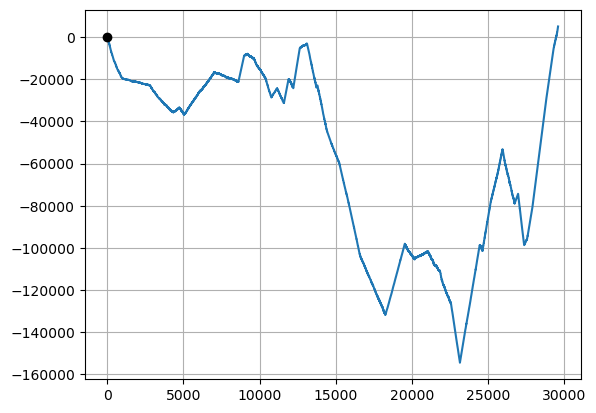

In [37]:
tsne = TSNE(random_state=42)
X_train_tsne = X.copy()
X_train_tsne = tsne.fit_transform(X_train_tsne)
components = tsne.embedding_
cumsum = np.cumsum(components)
n_components_tsne = np.argmax(cumsum >= 0.95) + 1
plt.plot(cumsum)
plt.plot([n_components_tsne, n_components_tsne], [0, 0.95], "k:")
plt.plot([0, n_components_tsne], [0.95, 0.95], "k:")
plt.plot(n_components_tsne, 0.95, "ko")
plt.grid()
plt.show()

In [ ]:
# lle = LocallyLinearEmbedding(random_state=42)
# X_train_lle = X.copy()
# X_train_lle = lle.fit_transform(X_train_lle)
# _, components = lle.embedding_
# cumsum = np.cumsum(components)
# n_components_lle = np.argmax(cumsum >= 0.95) + 1
# plt.plot(cumsum)
# plt.plot([n_components_lle, n_components_lle], [0, 0.95], "k:")
# plt.plot([0, n_components_lle], [0.95, 0.95], "k:")
# plt.plot(n_components_lle, 0.95, "ko")
# plt.grid()
# plt.show()

Pipeline

In [100]:
pca = PCA(n_components=n_components_pca, random_state=42)
tsne = TSNE(n_components=n_components_tsne, random_state=42)

pca_pipeline = Pipeline([
    ('scaler', PowerTransformer()) ,
    ('pca', pca),
])
tsne_pipeline = Pipeline([{
    'scaler', RobustScaler(),
    'tsne', tsne
}])


In [ ]:
# Depends on the data exploration step
# Additional processing like log, power, etc.

# log_pipeline = Pipeline([
#     ('log', FunctionTransformer(np.log1p))
# ])

# preprocessing_pipeline = ColumnTransformer([
#     ('pca', pca_pipeline, ['feature_1', 'feature_2', 'feature_3', 'feature_4']),
#     ('tsne', tsne_pipeline, ['feature_1', 'feature_2', 'feature_3', 'feature_4']),
#     ('lle', lle_pipeline, ['feature_1', 'feature_2', 'feature_3', 'feature_4'])
# ], remainder='passthrough')


## Processing data

In [ ]:
# Example of processing
# X_processed  = X.copy()
# X_processed = pca_pipeline.fit_transform(X_processed)

# Example of bypassing processing
# pca_pipeline.set_params(pca='passthrough')

#Examp for GridSearch/RandomizeSearch
# param_grid = {
#     'pca': [PCA(n_components=2), 'passthrough'],  # Use PCA or skip it
#     'clf__C': [0.1, 1.0, 10.0],
# }

In [101]:
Y = torgo['label']
X = torgo.drop('label', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42, n_jobs=-1)

model_pipeline = Pipeline ([
    ('preprocessing', pca_pipeline),
    ('forest', clf),
])

In [102]:
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint

param_grid = {
    'forest__n_estimators': [500, 700, 1000],
    'forest__max_depth': [50, 60, 100],
    'forest__max_features': ['sqrt', 'log2', None],
}

rnd_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)

rnd_search.fit(X_train, y_train)


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('scaler',
                                                         StandardScaler()),
                                                        ('pca',
                                                         PCA(n_components=np.int64(21),
                                                             random_state=42))])),
                                       ('forest',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'forest__max_depth': [50, 60, 100],
                         'forest__max_features': ['sqrt', 'log2', None],
                         'forest__n_estimators': [500, 700, 1000]},
             scoring='recall_macro')

In [105]:
joblib.dump(rnd_search.best_params_, 'best_params.pkl')
model = rnd_search.best_estimator_
joblib.dump(model, 'best_model.pkl')

rnd_search.best_params_

{'forest__max_depth': 50,
 'forest__max_features': 'sqrt',
 'forest__n_estimators': 700}

In [106]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [107]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred, average='macro'))
print(precision_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))


              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2065
           1       0.96      0.84      0.90       894

    accuracy                           0.94      2959
   macro avg       0.95      0.91      0.93      2959
weighted avg       0.94      0.94      0.94      2959

[[2037   28]
 [ 145  749]]
0.9415343021290977
0.9121241421150419
0.9487555841817987
0.9278672719589298
